scaler mean y: 58.337700739046234
scaler std  y: 7.119317273516296
scaler mean u: 63.08828052906798
scaler std  u: 23.987293259622874
ymin_scaled = -8.19428303273703
theta_abs = [0.60565999 0.37316012 0.00173492 0.00527164 0.80842119]
Operating point:
y_ss = 59.0
u_ss = 63.0
steady output at u_ss = 59.01043751947654
u_min_scaled = -1.7962960665344119
u_max_scaled = 1.5388030267285082
u_ss_scaled  = -0.0036803039055923778
y_target_scaled = 0.0930284794888275
A_koop shape: (10, 10)
B_koop shape: (10, 1)
C_koop shape: (1, 10)
Decoded y from true encoder x(target): 58.946653551995
Model-consistent target scaled: 0.08553528232462011
Simulating T0 = 45 °C
Simulating T0 = 50 °C
Simulating T0 = 55 °C
Simulating T0 = 60 °C
Simulating T0 = 62 °C
Simulating T0 = 66 °C
Simulating T0 = 68 °C


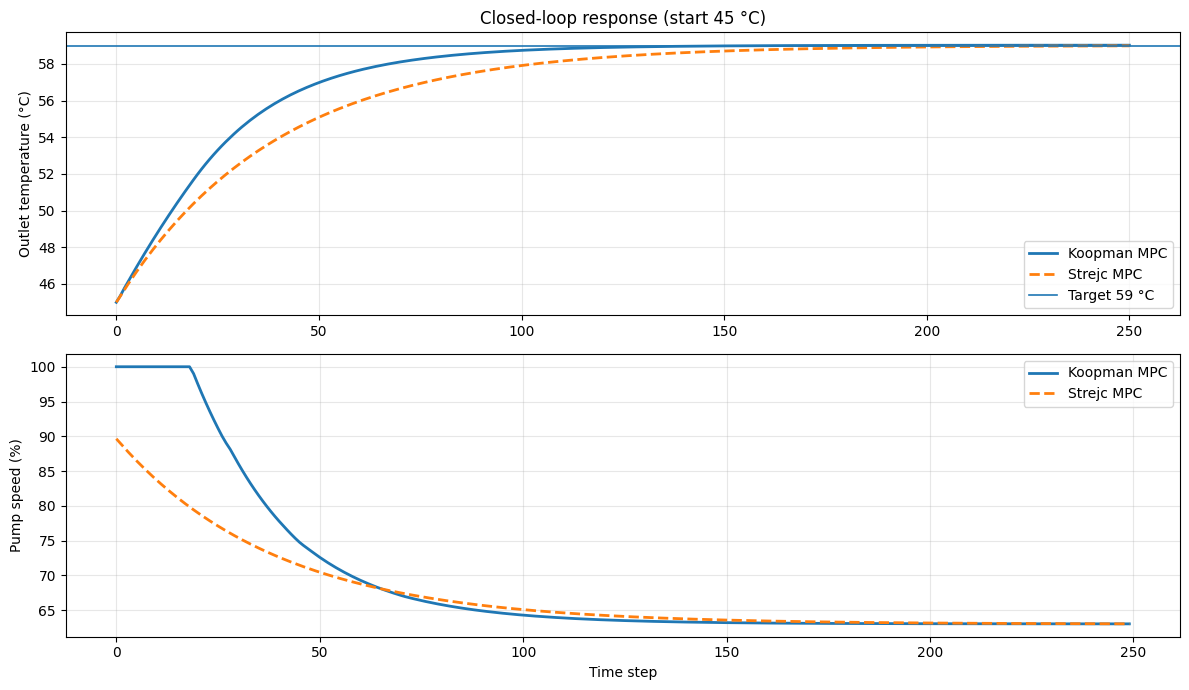

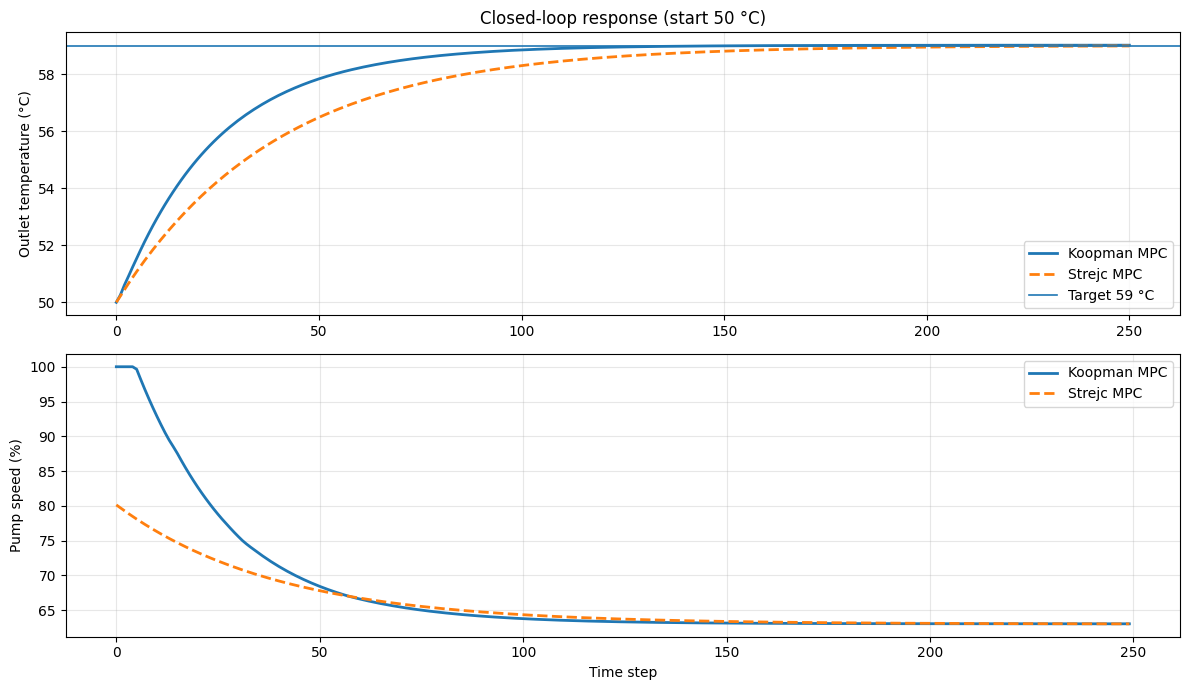

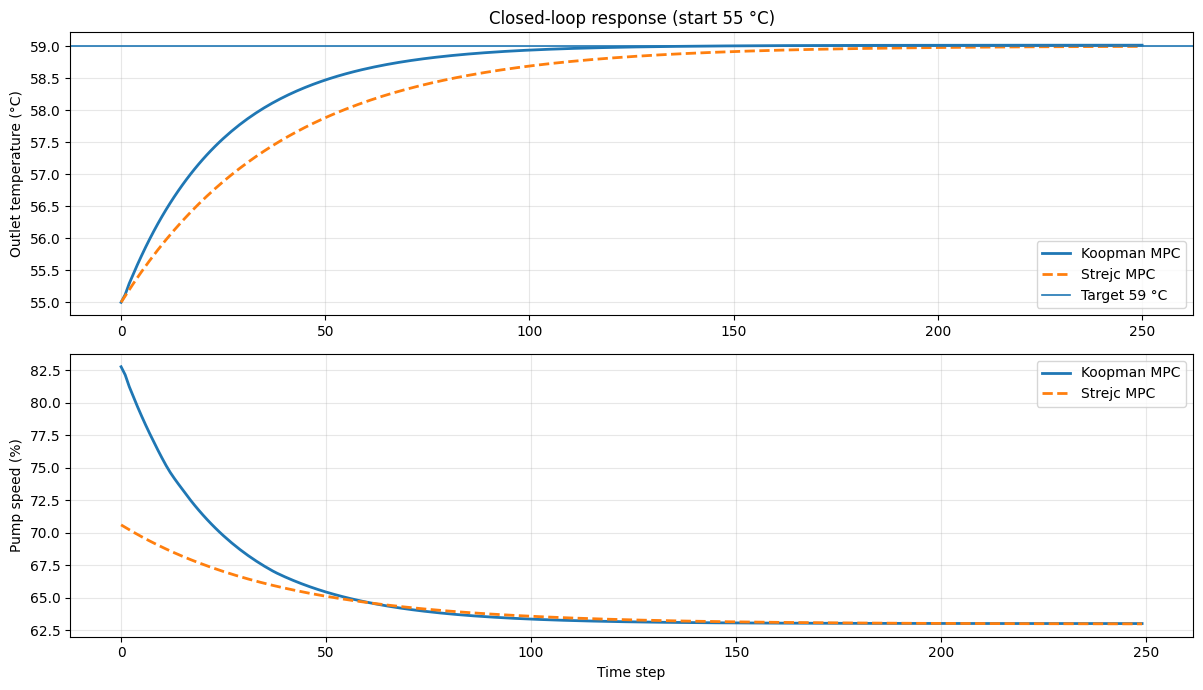

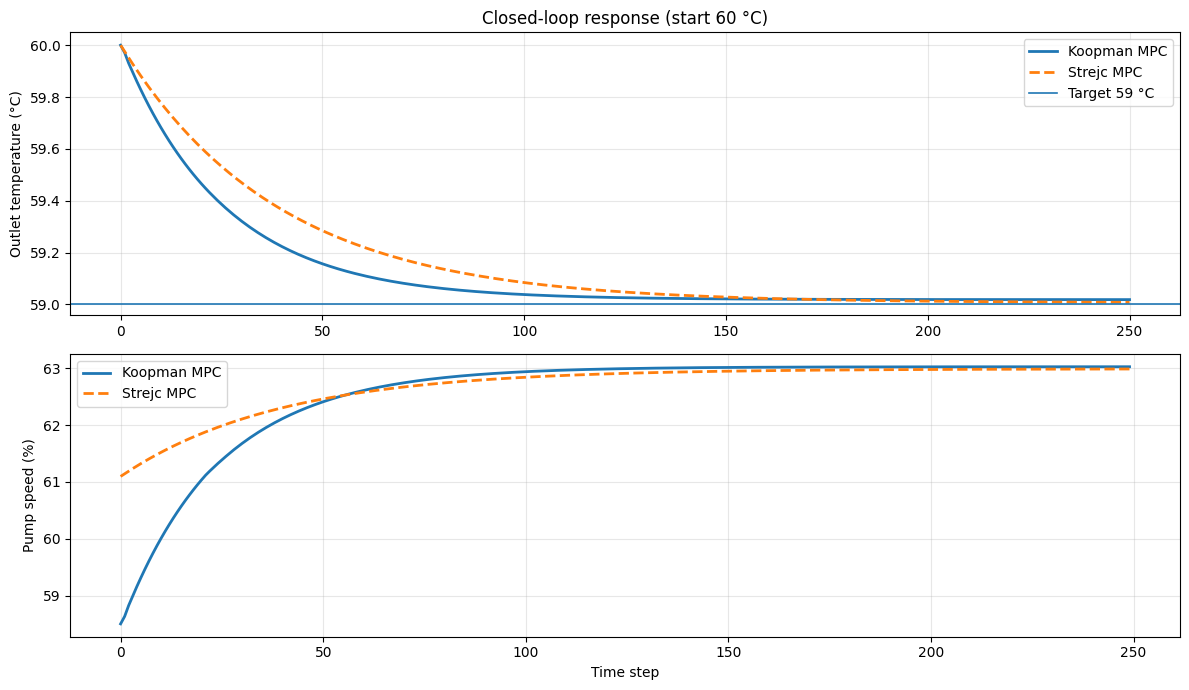

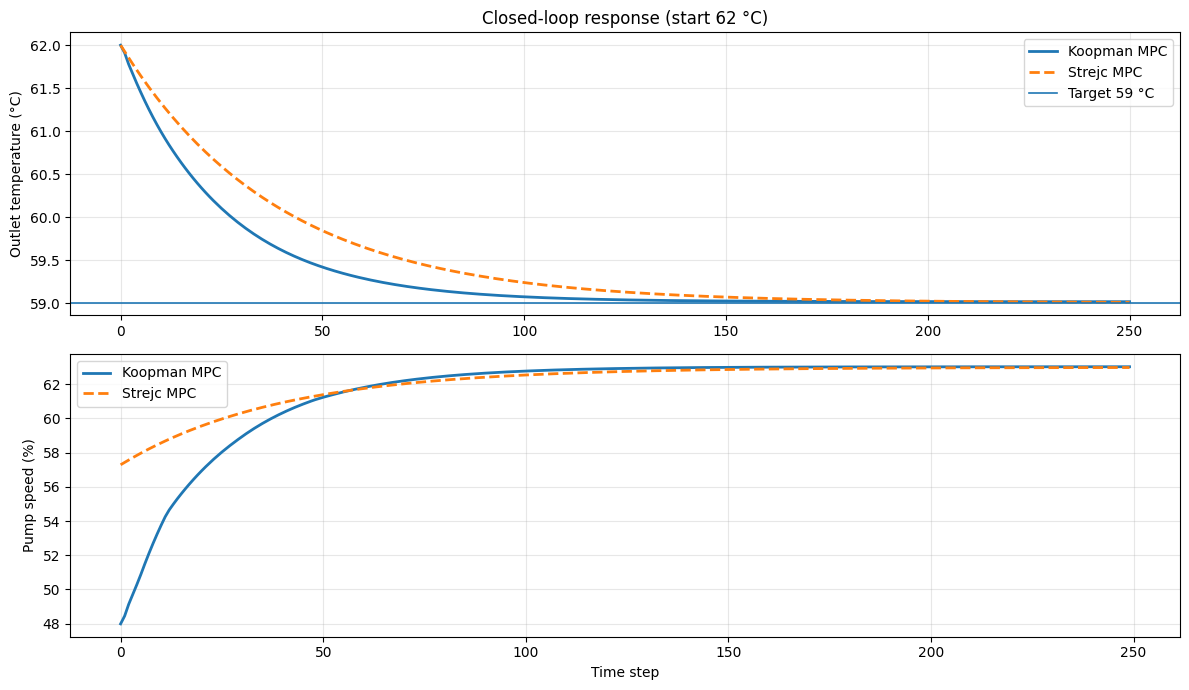

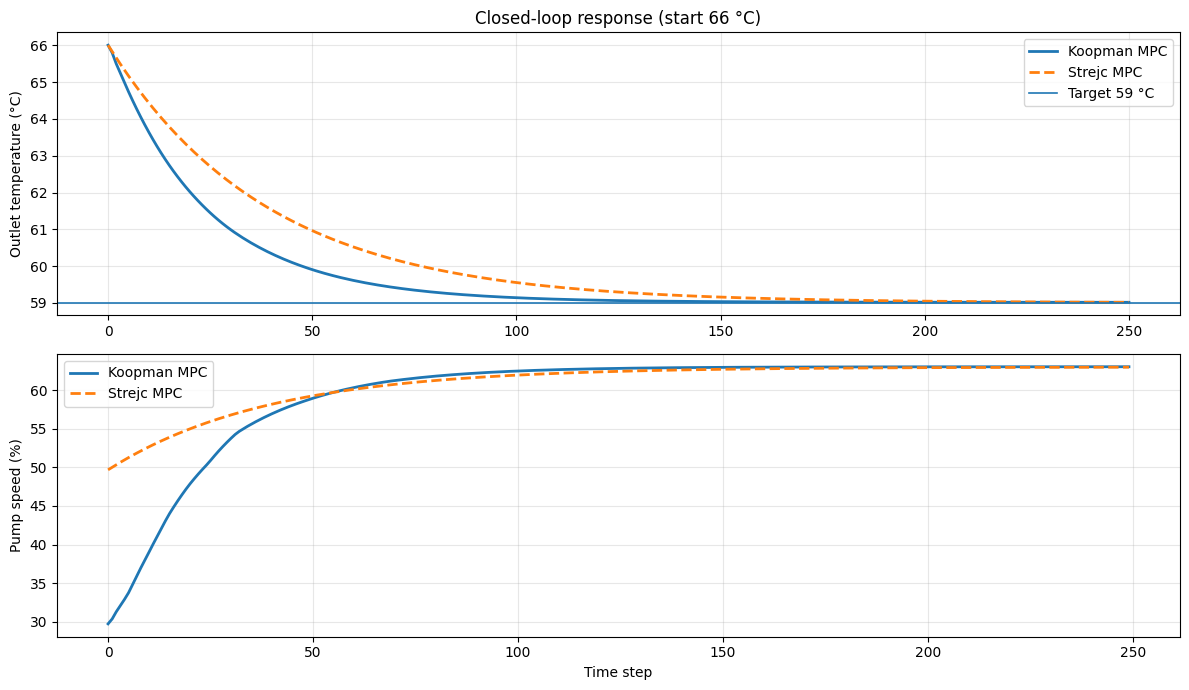

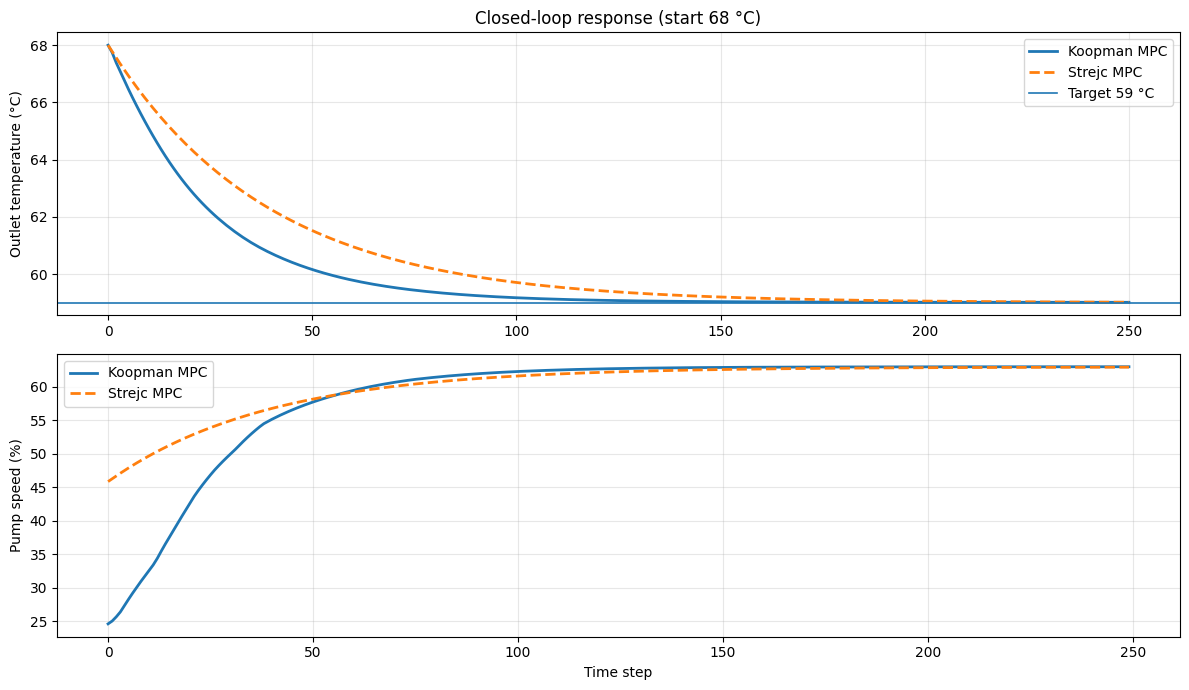

   T0    RMSE_K    RMSE_S       IAE_K       IAE_S         Obj_K         Obj_S
0  45  3.416313  3.973370  384.135268  554.688719  71354.305393  53764.282969
1  50  2.050799  2.553677  226.435310  356.103418  34116.161189  22207.911290
2  55  0.905894  1.133989  100.961466  157.518118   6821.107426   4379.184332
3  60  0.235372  0.285768   30.172966   41.067183    396.895485    278.102095
4  62  0.685019  0.853614   80.377834  120.501303   3800.867828   2481.409722
5  66  1.574239  1.989360  177.353590  279.369544  21467.807956  13477.294443
6  68  2.049015  2.557237  229.542918  358.803664  34350.067878  22269.871536

Extra checks:
u_ss = 63.0
u_ss_scaled = -0.0036803039055923778
y_target_scaled = 0.0930284794888275
y_ref_model_scaled = 0.08553528232462011
ymin_scaled = -8.19428303273703
Decoded y from true encoder x(target) = 58.946653551995


: 

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
import torch
import torch.nn as nn

from scipy.io import loadmat
from scipy.signal import cont2discrete

# ============================================================
# SETTINGS
# ============================================================
SEM2025_DIR = r"C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026"
MODEL_PATH = os.path.join(SEM2025_DIR, "data", "modelC.pth")

y_target = 59.0
u_min = 20.0
u_max = 100.0

temps = [45, 50, 55, 60, 62, 66, 68]
sim_length = 250

# Strejc MPC
N_strejc = 20
Qy_strejc = 10.0
Qu_strejc = 1.0

# Koopman MPC
N_koop = 20
Qy_koop = 10.0
Qx_koop = 1.0
QxN_koop = 100.0
Qu_koop = 1.0

torch.manual_seed(0)
np.random.seed(0)

# ============================================================
# LOAD DATA + SCALERS
# ============================================================
train_data = loadmat(os.path.join(SEM2025_DIR, "data", "train_data.mat"))
test_data = loadmat(os.path.join(SEM2025_DIR, "data", "test_data.mat"))

Ytrain = train_data["Ytrain"].reshape(-1)
Utrain = train_data["Utrain"].reshape(-1)
Ytest = test_data["Ytest"].reshape(-1)
Utest = test_data["Utest"].reshape(-1)

scaler = joblib.load(os.path.join(SEM2025_DIR, "data", "scaler.pkl"))
scalerU = joblib.load(os.path.join(SEM2025_DIR, "data", "scalerU.pkl"))

x_mean = float(scaler.mean_[0])
x_std = float(scaler.scale_[0])
u_mean = float(scalerU.mean_[0])
u_std = float(scalerU.scale_[0])

print("scaler mean y:", x_mean)
print("scaler std  y:", x_std)
print("scaler mean u:", u_mean)
print("scaler std  u:", u_std)

ymin_scaled = (0.0 - x_mean) / x_std
print("ymin_scaled =", ymin_scaled)

# ============================================================
# ABSOLUTE ARX PLANT
# ============================================================
def make_arx_abs_data(Y, U):
    X = []
    T = []
    for k in range(1, len(Y) - 1):
        X.append([Y[k], Y[k - 1], U[k], U[k - 1], 1.0])
        T.append(Y[k + 1])
    return np.array(X), np.array(T)

Xtr, Ttr = make_arx_abs_data(Ytrain, Utrain)
theta_abs, *_ = np.linalg.lstsq(Xtr, Ttr, rcond=None)
print("theta_abs =", theta_abs)

class ARXPlantAbs:
    def __init__(self, theta):
        self.theta = theta
        self.yk = None
        self.ykm1 = None
        self.ukm1 = None

    def reset(self, y0, u0):
        self.yk = float(y0)
        self.ykm1 = float(y0)
        self.ukm1 = float(u0)

    def step(self, uk):
        x = np.array([self.yk, self.ykm1, uk, self.ukm1, 1.0])
        y_next = float(x @ self.theta)
        self.ykm1 = self.yk
        self.yk = y_next
        self.ukm1 = float(uk)
        return y_next

def rollout_const_u_abs(theta, y0, u_const, n=500):
    plant = ARXPlantAbs(theta)
    plant.reset(y0, u_const)
    ys = [y0]
    for _ in range(n):
        ys.append(plant.step(u_const))
    return np.array(ys)

def final_temp_for_u(theta, y0, u_const, n=500, n_avg=100):
    ys = rollout_const_u_abs(theta, y0, u_const, n=n)
    return np.mean(ys[-n_avg:])

# ============================================================
# OPERATING POINT FOR TARGET 59 °C
# ============================================================
u_grid = np.linspace(20, 100, 801)
y_final = np.array([final_temp_for_u(theta_abs, y_target, u, n=500, n_avg=100) for u in u_grid])

idx = np.argmin(np.abs(y_final - y_target))
u_ss = float(u_grid[idx])
y_ss = y_target

print("Operating point:")
print("y_ss =", y_ss)
print("u_ss =", u_ss)
print("steady output at u_ss =", y_final[idx])

# Strejc bounds in physical deviation coordinates
dumin_phys = u_min - u_ss
dumax_phys = u_max - u_ss

# Koopman bounds in scaled absolute coordinates
u_min_scaled = scalerU.transform(np.array([[u_min]])).item()
u_max_scaled = scalerU.transform(np.array([[u_max]])).item()
u_ss_scaled = scalerU.transform(np.array([[u_ss]])).item()
y_target_scaled = scaler.transform(np.array([[y_target]])).item()

print("u_min_scaled =", u_min_scaled)
print("u_max_scaled =", u_max_scaled)
print("u_ss_scaled  =", u_ss_scaled)
print("y_target_scaled =", y_target_scaled)

# ============================================================
# REBUILD TRAINED ENCODER + EXTRACT MATRICES FROM modelC.pth
# ============================================================
ckpt = torch.load(MODEL_PATH, map_location="cpu")

class EncoderFY(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 60),
            nn.ReLU(),
            nn.Linear(60, 60),
            nn.ReLU(),
            nn.Linear(60, 60),
            nn.ReLU(),
            nn.Linear(60, 10),
        )

    def forward(self, x):
        return self.net(x)

encoder = EncoderFY()

with torch.no_grad():
    encoder.net[0].weight.copy_(ckpt["nodes.0.callable.linear.0.weight"])
    encoder.net[0].bias.copy_(ckpt["nodes.0.callable.linear.0.bias"])
    encoder.net[2].weight.copy_(ckpt["nodes.0.callable.linear.1.weight"])
    encoder.net[2].bias.copy_(ckpt["nodes.0.callable.linear.1.bias"])
    encoder.net[4].weight.copy_(ckpt["nodes.0.callable.linear.2.weight"])
    encoder.net[4].bias.copy_(ckpt["nodes.0.callable.linear.2.bias"])
    encoder.net[6].weight.copy_(ckpt["nodes.0.callable.linear.3.weight"])
    encoder.net[6].bias.copy_(ckpt["nodes.0.callable.linear.3.bias"])

encoder.eval()

A_koop = ckpt["nodes.3.nodes.0.callable.K.weight"].detach().cpu().numpy().astype(float)
B_koop = ckpt["nodes.2.callable.weight"].detach().cpu().numpy().astype(float)
C_koop = ckpt["nodes.4.callable.weight"].detach().cpu().numpy().astype(float)

print("A_koop shape:", A_koop.shape)
print("B_koop shape:", B_koop.shape)
print("C_koop shape:", C_koop.shape)

# ============================================================
# HELPER FUNCTIONS
# ============================================================
def y_phys_to_scaled(y_phys):
    return scaler.transform(np.array([[y_phys]], dtype=float)).item()

def u_phys_to_scaled(u_phys):
    return scalerU.transform(np.array([[u_phys]], dtype=float)).item()

def u_scaled_to_phys(u_scaled):
    return scalerU.inverse_transform(np.array([[u_scaled]], dtype=float)).item()

def decode_x_to_y_scaled(x_latent):
    return (C_koop @ x_latent).item()

def decode_x_to_y_phys(x_latent):
    y_scaled = decode_x_to_y_scaled(x_latent)
    return scaler.inverse_transform(np.array([[y_scaled]])).item()

def encode_y_to_x(y_phys):
    y_scaled = y_phys_to_scaled(y_phys)
    y_tensor = torch.tensor([[y_scaled]], dtype=torch.float32)
    with torch.no_grad():
        x = encoder(y_tensor).detach().cpu().numpy().reshape(-1, 1)
    return x

# model-consistent target
x_ref = encode_y_to_x(y_target)
y_ref_model_scaled = decode_x_to_y_scaled(x_ref)
y_ref_model_phys = decode_x_to_y_phys(x_ref)

print("Decoded y from true encoder x(target):", y_ref_model_phys)
print("Model-consistent target scaled:", y_ref_model_scaled)

# ============================================================
# STREJC MODEL
# ============================================================
gain = 1.1237
tau = 68.0
Ts = 1.0

A_c = np.array([[-1.0 / tau]])
B_c = np.array([[gain / tau]])
C_c = np.array([[1.0]])
D_c = np.array([[0.0]])

A_strejc, B_strejc, C_strejc, D_strejc, _ = cont2discrete(
    (A_c, B_c, C_c, D_c), Ts, method="zoh"
)

A_strejc = np.array(A_strejc, dtype=float)
B_strejc = np.array(B_strejc, dtype=float)
C_strejc = np.array(C_strejc, dtype=float)

# ============================================================
# MPC FUNCTIONS
# ============================================================
def mpc_strejc_dev(A, B, C, x0, yref, N=20, Qy=10.0, Qu=1.0,
                   dumin=None, dumax=None):
    nx = A.shape[0]

    U = cp.Variable((1, N))
    X = cp.Variable((nx, N + 1))

    constraints = [X[:, [0]] == x0.reshape(-1, 1)]
    objective = 0
    yref = np.array([[float(yref)]])

    for k in range(N):
        constraints += [X[:, [k+1]] == A @ X[:, [k]] + B @ U[:, [k]]]
        yk = C @ X[:, [k]]

        objective += Qy * cp.sum_squares(yk - yref)
        objective += Qu * cp.sum_squares(U[:, [k]])

        if dumin is not None:
            constraints += [U[:, [k]] >= dumin]
        if dumax is not None:
            constraints += [U[:, [k]] <= dumax]

    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return 0.0
    return float(U.value[0, 0])

def mpc_koopman_abs_scaled(A, B, C, x0, xref, yref_scaled,
                           N=20, Qy=10.0, Qx=1.0, QxN=100.0, Qu=1.0,
                           umin_scaled=None, umax_scaled=None,
                           ymin_scaled=None):
    nz = A.shape[0]

    U = cp.Variable((1, N))
    X = cp.Variable((nz, N + 1))

    constraints = [X[:, [0]] == x0.reshape(-1, 1)]
    objective = 0

    xref = xref.reshape(-1, 1)
    yref_scaled = float(yref_scaled)

    for k in range(N):
        constraints += [X[:, [k+1]] == A @ X[:, [k]] + B @ U[:, [k]]]
        yk = C @ X[:, [k]]

        if ymin_scaled is not None:
            constraints += [yk >= ymin_scaled]

        objective += Qy * cp.sum_squares(yk - yref_scaled)
        objective += Qx * cp.sum_squares(X[:, [k]] - xref)
        objective += Qu * cp.sum_squares(U[:, [k]] - u_ss_scaled)

        if umin_scaled is not None:
            constraints += [U[:, [k]] >= umin_scaled]
        if umax_scaled is not None:
            constraints += [U[:, [k]] <= umax_scaled]

    # strong terminal pull to steady state
    objective += QxN * cp.sum_squares(X[:, [N]] - xref)

    prob = cp.Problem(cp.Minimize(objective), constraints)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return float(u_ss_scaled)

    return float(U.value[0, 0])

# ============================================================
# CLOSED LOOP
# ============================================================
all_results = {}

for T0 in temps:
    print(f"Simulating T0 = {T0} °C")

    # ---------- Koopman MPC ----------
    plant_k = ARXPlantAbs(theta_abs)
    plant_k.reset(T0, u_ss)

    y_store_k = [T0]
    u_store_k = []
    u_store_k_scaled = []
    yhat_store_k = []

    for t in range(sim_length):
        y_now_phys = y_store_k[-1]
        x0_k = encode_y_to_x(y_now_phys)

        u_k_scaled = mpc_koopman_abs_scaled(
            A_koop, B_koop, C_koop,
            x0=x0_k,
            xref=x_ref,
            yref_scaled=y_ref_model_scaled,
            N=N_koop,
            Qy=Qy_koop,
            Qx=Qx_koop,
            QxN=QxN_koop,
            Qu=Qu_koop,
            umin_scaled=u_min_scaled,
            umax_scaled=u_max_scaled,
            ymin_scaled=ymin_scaled
        )

        u_k = u_scaled_to_phys(u_k_scaled)
        u_k = float(np.clip(u_k, u_min, u_max))

        yhat_now = decode_x_to_y_phys(x0_k)
        y_next = plant_k.step(u_k)

        y_store_k.append(y_next)
        u_store_k.append(u_k)
        u_store_k_scaled.append(u_k_scaled)
        yhat_store_k.append(yhat_now)

    # ---------- Strejc MPC ----------
    plant_s = ARXPlantAbs(theta_abs)
    plant_s.reset(T0, u_ss)

    x_s = np.array([[T0 - y_ss]])
    y_store_s = [T0]
    u_store_s = []

    for t in range(sim_length):
        du_s = mpc_strejc_dev(
            A_strejc, B_strejc, C_strejc,
            x_s, yref=0.0,
            N=N_strejc,
            Qy=Qy_strejc,
            Qu=Qu_strejc,
            dumin=dumin_phys,
            dumax=dumax_phys
        )

        u_s = u_ss + du_s
        u_s = float(np.clip(u_s, u_min, u_max))
        y_next = plant_s.step(u_s)

        x_s = np.array([[y_next - y_ss]])
        y_store_s.append(y_next)
        u_store_s.append(u_s)

    all_results[T0] = {
        "y_koop": np.array(y_store_k),
        "u_koop": np.array(u_store_k),
        "u_koop_scaled": np.array(u_store_k_scaled),
        "yhat_koop": np.array(yhat_store_k),
        "y_strejc": np.array(y_store_s),
        "u_strejc": np.array(u_store_s),
    }

# ============================================================
# PLOTS
# ============================================================
for T0 in temps:
    res = all_results[T0]

    tY = np.arange(sim_length + 1)
    tU = np.arange(sim_length)

    plt.figure(figsize=(12, 7))

    plt.subplot(2, 1, 1)
    plt.plot(tY, res["y_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tY, res["y_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.axhline(y_target, linewidth=1.2, label="Target 59 °C")
    plt.grid(True, alpha=0.3)
    plt.ylabel("Outlet temperature (°C)")
    plt.title(f"Closed-loop response (start {T0} °C)")
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(tU, res["u_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tU, res["u_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.grid(True, alpha=0.3)
    plt.xlabel("Time step")
    plt.ylabel("Pump speed (%)")
    plt.legend()

    plt.tight_layout()
    plt.show()

# ============================================================
# SUMMARY
# ============================================================
summary = []

for T0 in temps:
    res = all_results[T0]

    e_k = res["y_koop"][:-1] - y_target
    e_s = res["y_strejc"][:-1] - y_target

    rmse_k = np.sqrt(np.mean(e_k**2))
    rmse_s = np.sqrt(np.mean(e_s**2))

    iae_k = np.sum(np.abs(e_k))
    iae_s = np.sum(np.abs(e_s))

    du_k = res["u_koop"] - u_ss
    du_s = res["u_strejc"] - u_ss

    obj_k = np.sum(Qy_koop * e_k**2 + Qu_koop * du_k**2)
    obj_s = np.sum(Qy_strejc * e_s**2 + Qu_strejc * du_s**2)

    summary.append([T0, rmse_k, rmse_s, iae_k, iae_s, obj_k, obj_s])

summary_df = pd.DataFrame(
    summary,
    columns=["T0", "RMSE_K", "RMSE_S", "IAE_K", "IAE_S", "Obj_K", "Obj_S"]
)

print(summary_df)

# ============================================================
# EXTRA CHECKS
# ============================================================
print("\nExtra checks:")
print("u_ss =", u_ss)
print("u_ss_scaled =", u_ss_scaled)
print("y_target_scaled =", y_target_scaled)
print("y_ref_model_scaled =", y_ref_model_scaled)
print("ymin_scaled =", ymin_scaled)
print("Decoded y from true encoder x(target) =", decode_x_to_y_phys(x_ref))